<a href="https://colab.research.google.com/github/PinderMaksim/6.1.1/blob/main/Laba6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
!wget https://raw.githubusercontent.com/prasertcbs/basic-dataset/refs/heads/master/netflix_titles.csv

--2026-05-07 20:24:39--  https://raw.githubusercontent.com/prasertcbs/basic-dataset/refs/heads/master/netflix_titles.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2410660 (2.3M) [text/plain]
Saving to: ‘netflix_titles.csv’

netflix_titles.csv  100%[===================>]   2.30M  --.-KB/s    in 0.03s   

2026-05-07 20:24:39 (67.4 MB/s) - ‘netflix_titles.csv’ saved [2410660/2410660]



In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Зчитуємо дані
df = pd.read_csv('netflix_titles.csv')

# Налаштування стилю
plt.style.use('ggplot')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

!wget https://raw.githubusercontent.com/shivamb/netflix-shows/master/netflix_titles.csv

df = pd.read_csv('netflix_titles.csv')

plt.style.use('ggplot')

df.head()

--2026-05-07 20:33:43--  https://raw.githubusercontent.com/shivamb/netflix-shows/master/netflix_titles.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-07 20:33:43 ERROR 404: Not Found.



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


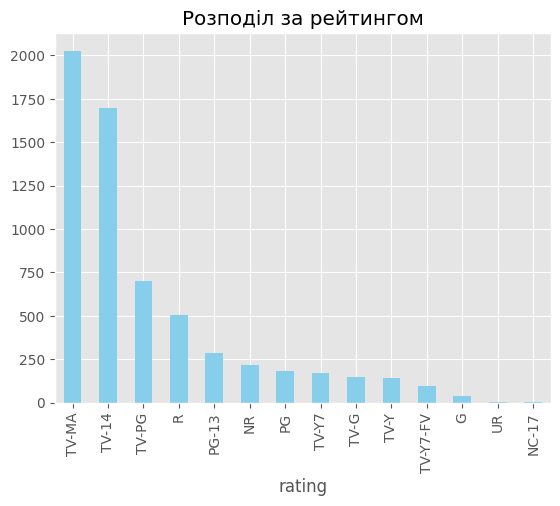

In [28]:
df['rating'].value_counts().plot(kind='bar', color='skyblue')

plt.title('Розподіл за рейтингом')

plt.show()

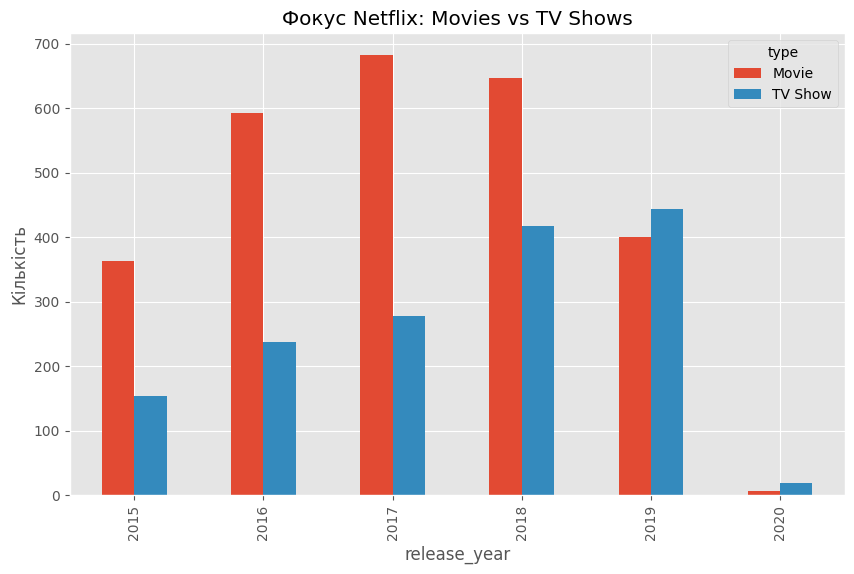

In [29]:
# Аналіз останніх 5 років
recent_5_years = df[df['release_year'] >= (df['release_year'].max() - 5)]

# Групування Movie та TV Show
recent_5_years.groupby(['release_year', 'type']).size().unstack().plot(
    kind='bar',
    figsize=(10,6)
)

# Заголовок графіка
plt.title('Фокус Netflix: Movies vs TV Shows')

# Підписи осей
plt.xlabel('release_year')
plt.ylabel('Кількість')

# Вивід графіка
plt.show()

In [30]:
# Дані за 2020 рік
df_2020 = df[df['release_year'] == 2020]

# Вивід країни з найбільшою та найменшою кількістю проєктів
print("Найбільше проєктів:", df_2020['country'].value_counts().idxmax())

print("Найменше проєктів:", df_2020['country'].value_counts().idxmin())

Найбільше проєктів: United States
Найменше проєктів: Spain


In [31]:
# Конвертуємо дату у формат datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# Створюємо колонку з назвою місяця
df['month_added'] = df['date_added'].dt.month_name()

# Вибираємо тільки серіали
tv_shows = df[df['type'] == 'TV Show']

# Знаходимо найпопулярніший місяць
popular_month = tv_shows['month_added'].value_counts().idxmax()

# Вивід результату
print(f"Найбільше серіалів на Netflix зазвичай виходить у місяці: {popular_month}")

Найбільше серіалів на Netflix зазвичай виходить у місяці: December


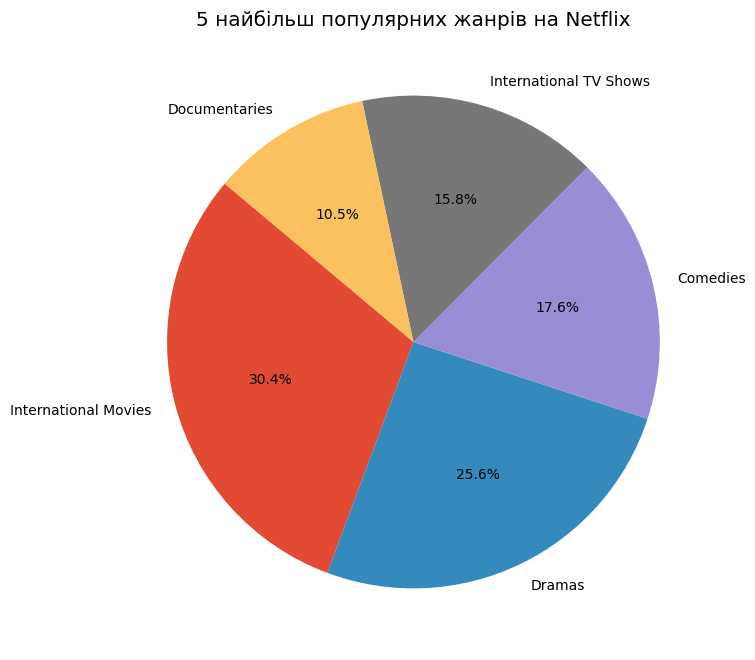

In [32]:
# Розділяємо жанри, якщо їх декілька в одному рядку
genres = df['listed_in'].str.split(', ').explode()

# Рахуємо ТОП-5 жанрів
top_5_genres = genres.value_counts().head(5)

# Будуємо кругову діаграму
plt.figure(figsize=(8,8))

top_5_genres.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140
)

# Заголовок
plt.title('5 найбільш популярних жанрів на Netflix')

# Прибираємо назву осі Y
plt.ylabel('')

# Відображення графіка
plt.show()